# Machine Learning-Based Analysis of Exoplanet Population Structure and Discovery Bias

### NASA Exoplanet Archive — Final analytical notebook

This notebook investigates whether machine-learning-derived exoplanet population structure is **robust astrophysical structure** or is substantially shaped by **observational selection, missing data, feature choice, and clustering assumptions**.

### Research questions

**RQ1.** Do machine-learning-derived exoplanet population regimes remain stable after accounting for missing data, feature redundancy, and clustering-model choice, and how strongly are they associated with discovery method?

**RQ2.** Is there independent evidence for a genuine low-density / multimodal separation between the regimes, and does any such separation persist within discovery methods that actually sample both sides of parameter space?


In [1]:
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency, gaussian_kde
from scipy.signal import find_peaks

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

try:
    from sklearn.cluster import HDBSCAN
    HDBSCAN_AVAILABLE = True
except Exception:
    HDBSCAN_AVAILABLE = False

print("HDBSCAN available:", HDBSCAN_AVAILABLE)


# Main discovery methods used throughout the analysis
major_methods = [
    "Transit",
    "Radial Velocity",
    "Imaging",
    "Microlensing"
]


HDBSCAN available: True


In [2]:
# Additional imports for the analyses
from scipy.stats import norm, rankdata
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
try:
    import diptest
except ImportError as e:
    raise ImportError("Install the dip test with:  pip install diptest") from e

def cramers_v(table):
    t = np.asarray(table)
    x2 = chi2_contingency(t)[0]
    return float(np.sqrt((x2 / t.sum()) / (min(t.shape) - 1)))

def make_copula_generator(Zsrc, rng_):
    """Null generator that keeps every column's marginal distribution AND the rank
    correlation between columns (Gaussian copula), but contains no cluster structure."""
    n_, p_ = Zsrc.shape
    U = np.column_stack([rankdata(Zsrc[:, j]) / (n_ + 1) for j in range(p_)])
    corr = np.corrcoef(norm.ppf(U).T)
    sorted_cols = [np.sort(Zsrc[:, j]) for j in range(p_)]
    def gen():
        g = rng_.multivariate_normal(np.zeros(p_), corr, size=n_)
        ranks = np.column_stack([rankdata(g[:, j], method="ordinal").astype(int) - 1 for j in range(p_)])
        return np.column_stack([sorted_cols[j][ranks[:, j]] for j in range(p_)])
    return gen


## 1. Data loading and construction of one consistent planet table

The NASA Exoplanet Archive can contain multiple parameter records for the same planet.  
To avoid mixing incompatible measurements, the analysis keeps only rows with `default_flag = 1` and confirms one row per planet.

### Table 1 — Data-cleaning summary

In [3]:
from pathlib import Path

DATA_PATH = Path("exoplanets_dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH.resolve()}\n"
        "Place exoplanets_dataset.csv in the same folder as this notebook."
    )

df_raw = pd.read_csv(
    DATA_PATH,
    comment="#",
    low_memory=False
)

required_columns = {
    "pl_name",
    "default_flag",
    "discoverymethod"
}

missing_required = required_columns.difference(df_raw.columns)

if missing_required:
    raise ValueError(
        "Required dataset columns are missing: "
        f"{sorted(missing_required)}"
    )

print("Raw shape:", df_raw.shape)

summary = []
summary.append(
    ["Raw", len(df_raw), df_raw["pl_name"].nunique()]
)

df = df_raw.loc[
    df_raw["default_flag"].eq(1)
].copy()

summary.append(
    ["default_flag = 1", len(df), df["pl_name"].nunique()]
)

duplicate_planets = int(
    df["pl_name"].duplicated().sum()
)

if duplicate_planets:
    df = df.drop_duplicates(
        "pl_name",
        keep="first"
    ).copy()

summary.append(
    [
        "Final unique-planet table",
        len(df),
        df["pl_name"].nunique()
    ]
)

display(
    pd.DataFrame(
        summary,
        columns=[
            "Stage",
            "Rows",
            "Unique planets"
        ]
    )
)

print(
    "Duplicate planet names after default filtering:",
    duplicate_planets
)


Raw shape: (39386, 92)


,Stage,Rows,Unique planets
0,Raw,39386,6107
1,default_flag = 1,6107,6107
2,Final unique-planet table,6107,6107


Duplicate planet names after default filtering: 0


## 2. Feature selection

The primary feature set intentionally avoids redundant derived quantities such as `st_logg` and `pl_orbsmax`. Planet radius is included because it is a major observable for transit discoveries.

### Table 2 — Selected features and physical meaning

In [4]:
print("=" * 70)
print("TABLE 2: FEATURE SELECTION")
print("=" * 70)

FEATURE_INFO = pd.DataFrame({
    "Feature": ["pl_bmasse","pl_rade","pl_orbper","st_teff","st_mass","st_rad","st_met"],
    "Physical meaning": [
        "Planet mass (Earth masses)",
        "Planet radius (Earth radii)",
        "Orbital period (days)",
        "Host-star effective temperature (K)",
        "Host-star mass (solar masses)",
        "Host-star radius (solar radii)",
        "Host-star metallicity (dex)"
    ],
    "Role": ["Planetary","Planetary","Orbital","Stellar","Stellar","Stellar","Stellar"],
    "Reason for inclusion": [
        "Describes planetary mass regime",
        "Major directly measured quantity for transit discoveries",
        "Describes orbital timescale",
        "Describes host-star thermal state",
        "Describes host-star mass",
        "Describes host-star size",
        "Describes host-star chemical composition"
    ]
})
FEATURES = FEATURE_INFO["Feature"].tolist()
LOG_FEATURES = ["pl_bmasse","pl_rade","pl_orbper","st_mass","st_rad"]
display(FEATURE_INFO)
print(
    f"SUMMARY: {len(FEATURES)} primary features selected "
    "(2 planetary, 1 orbital, 4 stellar)."
)


TABLE 2: FEATURE SELECTION


,Feature,Physical meaning,Role,Reason for inclusion
0,pl_bmasse,Planet mass (Earth masses),Planetary,Describes planetary mass regime
1,pl_rade,Planet radius (Earth radii),Planetary,Major directly measured quantity for transit d...
2,pl_orbper,Orbital period (days),Orbital,Describes orbital timescale
3,st_teff,Host-star effective temperature (K),Stellar,Describes host-star thermal state
4,st_mass,Host-star mass (solar masses),Stellar,Describes host-star mass
5,st_rad,Host-star radius (solar radii),Stellar,Describes host-star size
6,st_met,Host-star metallicity (dex),Stellar,Describes host-star chemical composition


SUMMARY: 7 primary features selected (2 planetary, 1 orbital, 4 stellar).


## 3. Missing-data structure

Missing values are not assumed to be random. In exoplanet catalogues, what is measured often depends on how a planet was discovered.

### Table 3A — Overall missingness  
### Table 3B — Missingness by major discovery method

In [5]:
print("=" * 70)
print("TABLE 3A: Overall missingness")
print("=" * 70)

missing = pd.DataFrame({
    "Feature": FEATURES,
    "Missing count": [df[c].isna().sum() for c in FEATURES],
    "Missing %": [100*df[c].isna().mean() for c in FEATURES]
}).sort_values("Missing %", ascending=False)
display(missing.round(2))

print("=" * 70)
print("TABLE 3B: Missingness by major discovery method")
print("=" * 70)

rows=[]
for method in major_methods:
    sub=df[df["discoverymethod"].eq(method)]
    if len(sub)==0: continue
    row={"Discovery method":method,"N":len(sub)}
    for c in FEATURES: row[c+" missing %"] = 100*sub[c].isna().mean()
    rows.append(row)
missing_by_method=pd.DataFrame(rows).set_index("Discovery method")
display(missing_by_method.round(1))

complete_mask = df[FEATURES].notna().all(axis=1)
print("Complete cases:", int(complete_mask.sum()), "of", len(df), f"({100*complete_mask.mean():.1f}%)")

print(
    "SUMMARY: Missingness is discovery-method dependent, so later "
    "robustness checks use complete cases and alternative features."
)


TABLE 3A: Overall missingness


,Feature,Missing count,Missing %
0,pl_bmasse,3103,50.81
6,st_met,1791,29.33
1,pl_rade,1563,25.59
5,st_rad,795,13.02
4,st_mass,770,12.61
3,st_teff,710,11.63
2,pl_orbper,344,5.63


TABLE 3B: Missingness by major discovery method


,N,pl_bmasse missing %,pl_rade missing %,pl_orbper missing %,st_teff missing %,st_mass missing %,st_rad missing %,st_met missing %
Discovery method,,,,,,,,
Transit,4501,68.5,0.6,0.3,2.4,16.1,0.8,23.6
Radial Velocity,1166,0.3,97.3,0.1,22.0,1.0,33.4,28.9
Imaging,92,3.3,70.7,76.1,52.2,27.2,83.7,81.5
Microlensing,266,0.0,100.0,95.9,98.1,0.0,100.0,99.6


Complete cases: 1274 of 6107 (20.9%)
SUMMARY: Missingness is discovery-method dependent, so later robustness checks use complete cases and alternative features.


## 4. Preprocessing

Numerical preprocessing is applied consistently before PCA and clustering.

1. **Median imputation** handles missing numerical values in the primary analysis.
2. Strongly right-skewed positive features are transformed with `log10(x + 1)`.
3. All features are standardized with `StandardScaler`.

### Table 4 — Transformation, imputation, and standardization

In [6]:
def preprocess(data, features, impute=True):
    X=data[features].copy()
    medians=None
    if impute:
        imp=SimpleImputer(strategy="median")
        X=pd.DataFrame(imp.fit_transform(X), columns=features, index=data.index)
        medians=pd.Series(imp.statistics_, index=features, name="Imputation median")
    else:
        if X.isna().any().any(): raise ValueError("Complete-case preprocessing received missing values")
    log_cols=[c for c in ["pl_bmasse","pl_rade","pl_orbper","st_mass","st_rad"] if c in features]
    for c in log_cols:
        if (X[c] < 0).any(): raise ValueError(f"Negative values found in {c}")
        X[c]=np.log10(X[c]+1)
    scaler=StandardScaler()
    Z=scaler.fit_transform(X)
    return X, Z, medians, scaler

X_full, Z_full, medians, scaler_full = preprocess(df, FEATURES, impute=True)


# Formal preprocessing reference table
transformation_df = pd.DataFrame({
    "Feature": FEATURES,
    "Log Transform": [
        "Yes (log10(x+1))" if f in LOG_FEATURES else "No"
        for f in FEATURES
    ],
    "Standardization": ["Yes (StandardScaler)"] * len(FEATURES),
    "Imputation Method": ["Median"] * len(FEATURES)
})

print("=" * 70)
print("TABLE 4: DATA TRANSFORMATION METHODS")
print("=" * 70)
display(transformation_df)

print("Imputation medians used in the primary analysis:")
display(medians.to_frame().round(4))

print(
    "SUMMARY: Strongly skewed positive variables are log-transformed, "
    "all selected features are standardized, and the primary analysis "
    "uses median imputation."
)


TABLE 4: DATA TRANSFORMATION METHODS


,Feature,Log Transform,Standardization,Imputation Method
0,pl_bmasse,Yes (log10(x+1)),Yes (StandardScaler),Median
1,pl_rade,Yes (log10(x+1)),Yes (StandardScaler),Median
2,pl_orbper,Yes (log10(x+1)),Yes (StandardScaler),Median
3,st_teff,No,Yes (StandardScaler),Median
4,st_mass,Yes (log10(x+1)),Yes (StandardScaler),Median
5,st_rad,Yes (log10(x+1)),Yes (StandardScaler),Median
6,st_met,No,Yes (StandardScaler),Median


Imputation medians used in the primary analysis:


,Imputation median
pl_bmasse,171.3105
pl_rade,2.4300
pl_orbper,11.1313
st_teff,5550.0000
st_mass,0.9420
st_rad,0.9500
st_met,0.0200


SUMMARY: Strongly skewed positive variables are log-transformed, all selected features are standardized, and the primary analysis uses median imputation.


##### Log transformation reduces extreme skew in mass, radius, period, and stellar size variables. Standardization prevents variables measured on large numerical scales, such as stellar temperature, from dominating distance-based clustering.

## 5. Observational selection before clustering

Before any ML model is fitted, the observed mass–period plane is plotted by discovery method.

### Figure 1 — Observed planet mass vs orbital period by discovery method

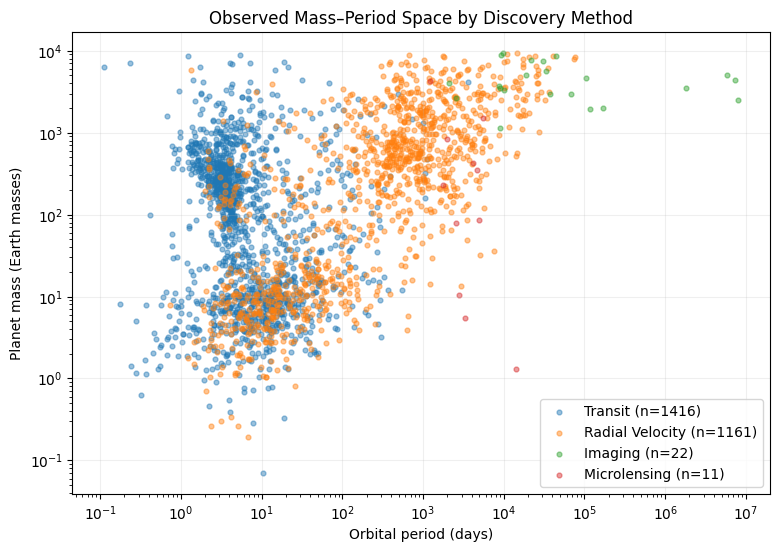

sklearn.decomposition._pca.PCA

In [7]:
plot_df=df[df["discoverymethod"].isin(major_methods) & df["pl_bmasse"].gt(0) & df["pl_orbper"].gt(0)].copy()
plt.figure(figsize=(9,6))
for method in major_methods:
    s=plot_df[plot_df["discoverymethod"].eq(method)]
    if len(s): plt.scatter(s["pl_orbper"],s["pl_bmasse"],s=12,alpha=.45,label=f"{method} (n={len(s)})")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Orbital period (days)"); plt.ylabel("Planet mass (Earth masses)")
plt.title("Observed Mass–Period Space by Discovery Method")
plt.legend(); plt.grid(alpha=.2); plt.show()
PCA

## 6. Principal Component Analysis (PCA)

PCA is used descriptively to show which combinations of variables dominate variance in the standardized feature space.

### Table 5A — PCA explained variance  
### Table 5B — PC1–PC3 loadings  
### Table 5C — Physical interpretation of the leading PCs

In [8]:
pca = PCA().fit(Z_full)

variance = pd.DataFrame({
    "Component":[f"PC{i+1}" for i in range(len(FEATURES))],
    "Explained variance %":100*pca.explained_variance_ratio_,
    "Cumulative %":100*np.cumsum(pca.explained_variance_ratio_)
})

loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=variance["Component"]
)

pc_interpretation = pd.DataFrame({
    "Component":["PC1","PC2","PC3"],
    "Largest absolute loadings":[
        "st_mass, st_rad, pl_bmasse",
        "st_met, pl_orbper, pl_rade",
        "st_teff, st_met, pl_bmasse"
    ],
    "Interpretation":[
        "Broad stellar/system mass-size dimension",
        "Metallicity–orbital-period–planet-radius contrast",
        "Stellar-temperature / metallicity–planet-mass contrast"
    ]
})

print("=" * 70)
print("TABLE 1: PCA LOADINGS")
print("=" * 70)
display(loadings[["PC1", "PC2", "PC3"]].round(3))
display(pc_interpretation)

print("=" * 70)
print("TABLE 2: PCA EXPLAINED VARIANCE")
print("=" * 70)
display(variance.round(2))

print(
    f"SUMMARY: PC1-PC3 explain "
    f"{variance.loc[2, 'Cumulative %']:.1f}% of total standardized variance."
)


TABLE 1: PCA LOADINGS


Component,PC1,PC2,PC3
pl_bmasse,0.442,-0.111,-0.366
pl_rade,0.266,0.520,-0.183
pl_orbper,0.301,-0.527,-0.310
st_teff,0.283,0.259,0.661
st_mass,0.548,0.062,0.237
st_rad,0.489,-0.250,0.122
st_met,0.152,0.553,-0.479


,Component,Largest absolute loadings,Interpretation
0,PC1,"st_mass, st_rad, pl_bmasse",Broad stellar/system mass-size dimension
1,PC2,"st_met, pl_orbper, pl_rade",Metallicity–orbital-period–planet-radius contrast
2,PC3,"st_teff, st_met, pl_bmasse",Stellar-temperature / metallicity–planet-mass ...


TABLE 2: PCA EXPLAINED VARIANCE


,Component,Explained variance %,Cumulative %
0,PC1,31.91,31.91
1,PC2,18.28,50.20
2,PC3,13.32,63.51
3,PC4,12.51,76.03
4,PC5,11.04,87.07
5,PC6,8.17,95.24
6,PC7,4.76,100.00


SUMMARY: PC1-PC3 explain 63.5% of total standardized variance.


##### PC1 explains about **31.9%** of the variance and is driven mainly by stellar mass, stellar radius, and planet mass. PC2 adds about **18.3%** and contrasts metallicity/radius with orbital period. PC3 adds about **13.3%** and is dominated by stellar temperature, metallicity, and planet mass. Together, the first three PCs explain about **63.5%** of the standardized variance.



## 7. How many KMeans clusters are preferred?

KMeans solutions from `k = 2` to `k = 8` are compared using silhouette score.

### Table 6 — KMeans silhouette by number of clusters  
### Figure 2 — Silhouette profile

,k,Silhouette
0,2,0.279
1,3,0.339
2,4,0.327
3,5,0.290
4,6,0.306
5,7,0.290
6,8,0.296


Best KMeans k by silhouette: 3


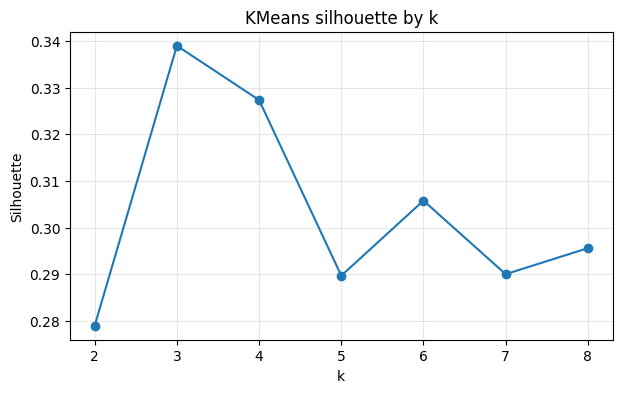

SUMMARY: KMeans model selection — best k = 3, silhouette = 0.339.


In [9]:
k_rows=[]
for k in range(2,9):
    km=KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=50).fit(Z_full)
    k_rows.append([k,silhouette_score(Z_full,km.labels_)])
k_table=pd.DataFrame(k_rows,columns=["k","Silhouette"])
display(k_table.round(3))
best_k=int(k_table.loc[k_table["Silhouette"].idxmax(),"k"])
print("Best KMeans k by silhouette:",best_k)

plt.figure(figsize=(7,4)); plt.plot(k_table["k"],k_table["Silhouette"],marker="o")
plt.xlabel("k");plt.ylabel("Silhouette");plt.title("KMeans silhouette by k");plt.grid(alpha=.3);plt.show()

print(
    f"SUMMARY: KMeans model selection — best k = {best_k}, "
    f"silhouette = "
    f"{k_table.loc[k_table['k'].eq(best_k), 'Silhouette'].iloc[0]:.3f}."
)


##### The strongest KMeans silhouette occurs at **k = 3**, not at two clusters. This is important because the earlier two-regime narrative should not be assumed from the outset. Even the selected solution is treated as a descriptive partition rather than proof of 3 natural planet classes.

## 8. Comparison of clustering models

Different algorithms impose different assumptions on the data. KMeans, Gaussian Mixture Models, hierarchical clustering, and HDBSCAN are therefore compared side by side.

### Table 7 — Model comparison: clusters, noise, silhouette, and ARI  
### Table 8 — Pairwise ARI among partitioning models

In [10]:
print("=" * 70)
print("TABLE 6: CLUSTERING MODEL COMPARISON")
print("=" * 70)

km = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=50
).fit(Z_full)
lab_km = km.labels_

gmm = GaussianMixture(
    n_components=best_k,
    random_state=RANDOM_STATE,
    n_init=5
).fit(Z_full)
lab_gmm = gmm.predict(Z_full)

hier = AgglomerativeClustering(
    n_clusters=best_k
).fit(Z_full)
lab_hier = hier.labels_

comparison_rows = [
    [
        "KMeans",
        best_k,
        0,
        silhouette_score(Z_full, lab_km),
        "all points",
        1.000
    ],
    [
        "GMM",
        len(np.unique(lab_gmm)),
        0,
        silhouette_score(Z_full, lab_gmm),
        "all points",
        adjusted_rand_score(lab_km, lab_gmm)
    ],
    [
        "Hierarchical",
        len(np.unique(lab_hier)),
        0,
        silhouette_score(Z_full, lab_hier),
        "all points",
        adjusted_rand_score(lab_km, lab_hier)
    ]
]

if HDBSCAN_AVAILABLE:
    hdb = HDBSCAN(min_cluster_size=20).fit(Z_full)
    lab_hdb = hdb.labels_
    hmask = lab_hdb != -1
    hdb_clusters = len(set(lab_hdb)) - (1 if -1 in lab_hdb else 0)

    comparison_rows.append([
        "HDBSCAN",
        hdb_clusters,
        int((~hmask).sum()),
        (
            silhouette_score(Z_full[hmask], lab_hdb[hmask])
            if hdb_clusters >= 2 else np.nan
        ),
        "non-noise points only",
        (
            adjusted_rand_score(lab_km[hmask], lab_hdb[hmask])
            if hdb_clusters >= 2 else np.nan
        )
    ])
else:
    hdb = None
    lab_hdb = np.full(len(Z_full), -1)
    hmask = np.zeros(len(Z_full), dtype=bool)
    hdb_clusters = 0
    comparison_rows.append([
        "HDBSCAN",
        np.nan,
        np.nan,
        np.nan,
        "not available in this environment",
        np.nan
    ])

model_comparison = pd.DataFrame(
    comparison_rows,
    columns=[
        "Method",
        "Clusters",
        "Noise points",
        "Silhouette",
        "Silhouette scope",
        "ARI vs KMeans"
    ]
)

display(model_comparison.round(3))

labels_dict = {
    "KMeans": lab_km,
    "GMM": lab_gmm,
    "Hierarchical": lab_hier
}

ari = pd.DataFrame(
    index=labels_dict,
    columns=labels_dict,
    dtype=float
)

for model_a in labels_dict:
    for model_b in labels_dict:
        ari.loc[model_a, model_b] = adjusted_rand_score(
            labels_dict[model_a],
            labels_dict[model_b]
        )

display(ari.round(3))

print(
    "SUMMARY: KMeans-Hierarchical ARI = "
    f"{ari.loc['KMeans', 'Hierarchical']:.3f}; "
    "KMeans-GMM ARI = "
    f"{ari.loc['KMeans', 'GMM']:.3f}."
)


TABLE 6: CLUSTERING MODEL COMPARISON


,Method,Clusters,Noise points,Silhouette,Silhouette scope,ARI vs KMeans
0,KMeans,3,0,0.339,all points,1.000
1,GMM,3,0,0.004,all points,0.226
2,Hierarchical,3,0,0.335,all points,0.824
3,HDBSCAN,2,1033,0.387,non-noise points only,0.064


,KMeans,GMM,Hierarchical
KMeans,1.000,0.226,0.824
GMM,0.226,1.000,0.204
Hierarchical,0.824,0.204,1.000


SUMMARY: KMeans-Hierarchical ARI = 0.824; KMeans-GMM ARI = 0.226.


KMeans and hierarchical clustering agree relatively well (**ARI ≈ 0.824**), but GMM agrees weakly with KMeans (**ARI ≈ 0.226**). HDBSCAN identifies a large noise set, so its silhouette is calculated only on non-noise points and is **not directly comparable** with all-point silhouette scores. The exact partition therefore depends on modelling assumptions.

## 9. Physical cluster profiles

The primary KMeans regimes are characterized in the original physical units. Both median and mean values are shown; medians are emphasized because several exoplanet quantities are highly skewed.

### Table 9A — Cluster sizes  
### Table 9B — Median physical profiles  
### Table 9C — Mean physical profiles

In [11]:
print("=" * 70)
print("TABLE 9A: Cluster Profiles")
print("=" * 70)

clustered = df[["pl_name","discoverymethod"] + FEATURES].copy()
clustered["cluster"] = lab_km

print("Cluster sizes")
display(clustered["cluster"].value_counts().sort_index().to_frame("N"))

print("=" * 70)
print("TABLE 9B: Median Physical Profiles — observed values only")
print("=" * 70)

display(clustered.groupby("cluster")[FEATURES].median().round(3))

print("=" * 70)
print("TABLE 9C: Mean Physical Profiles — observed values only")
print("=" * 70)
display(clustered.groupby("cluster")[FEATURES].mean().round(3))
print(
    f"SUMMARY: {clustered['cluster'].nunique()} data-driven regimes "
    "were profiled in the original physical units."
)


TABLE 9A: Cluster Profiles
Cluster sizes


,N
cluster,
0,695
1,4421
2,991


TABLE 9B: Median Physical Profiles — observed values only


,pl_bmasse,pl_rade,pl_orbper,st_teff,st_mass,st_rad,st_met
cluster,,,,,,,
0,1031.197,6.400,989.600,5329.0,1.15,2.060,0.04
1,12.500,2.094,10.424,5470.0,0.87,0.883,0.00
2,301.938,12.414,4.188,5854.0,1.10,1.238,0.12


TABLE 9C: Mean Physical Profiles — observed values only


,pl_bmasse,pl_rade,pl_orbper,st_teff,st_mass,st_rad,st_met
cluster,,,,,,,
0,1832.664,7.610,37016.394,5279.874,1.291,6.867,0.008
1,330.042,2.235,42.290,5220.019,0.823,0.904,-0.016
2,697.241,12.462,37.931,6143.117,1.143,1.330,0.114


SUMMARY: 3 data-driven regimes were profiled in the original physical units.


##### The regimes differ in planet mass/radius, orbital period, and host-star properties. These differences describe the KMeans partition, but they do not by themselves prove distinct formation classes. The later robustness and discovery-bias tests determine how much confidence should be placed in this physical separation.

## 10. Discovery method × cluster relationship

Discovery method was not used to create the clusters. It is now brought back to test whether cluster membership is associated with how planets were detected.

Rare methods are collapsed into **Other** before the chi-square test to avoid many near-empty cells.

### Table 10A — Discovery-method counts by cluster  
### Table 10B — Discovery-method percentages within cluster

In [12]:
print("DISCOVERY METHOD × CLUSTER CONTINGENCY TABLE")


method_counts=clustered["discoverymethod"].value_counts(dropna=False)
keep_methods=method_counts[method_counts>=50].index
clustered["method_group"]=clustered["discoverymethod"].where(clustered["discoverymethod"].isin(keep_methods),"Other")
ct=pd.crosstab(clustered["cluster"],clustered["method_group"])
pct=pd.crosstab(clustered["cluster"],clustered["method_group"],normalize="index")*100
print("=" * 70)
print("TABLE 10A: Discovery-method counts by cluster")
print("=" * 70)
display(ct) 
print("=" * 70)
print("TABLE 10B: Discovery-method percentages within cluster")
print("=" * 70)
display(pct.round(2))

chi2,p,dof,expected=chi2_contingency(ct)
n=ct.to_numpy().sum(); r,c=ct.shape
V=np.sqrt((chi2/n)/min(r-1,c-1))
print(f"Chi-square={chi2:.3f}, dof={dof}, p={p:.3e}, Cramer's V={V:.3f}")
print("Minimum expected cell count:",expected.min())

print(
    f"SUMMARY: Discovery-method association tested — "
    f"Cramer's V = {V:.3f}; "
    f"minimum expected cell count = {expected.min():.2f}."
)


DISCOVERY METHOD × CLUSTER CONTINGENCY TABLE
TABLE 10A: Discovery-method counts by cluster


method_group,Imaging,Microlensing,Other,Radial Velocity,Transit
cluster,,,,,
0,23,7,19,616,30
1,44,259,46,539,3533
2,25,0,17,11,938


TABLE 10B: Discovery-method percentages within cluster


method_group,Imaging,Microlensing,Other,Radial Velocity,Transit
cluster,,,,,
0,3.31,1.01,2.73,88.63,4.32
1,1.00,5.86,1.04,12.19,79.91
2,2.52,0.00,1.72,1.11,94.65


Chi-square=2702.055, dof=8, p=0.000e+00, Cramer's V=0.470
Minimum expected cell count: 9.331914196823318
SUMMARY: Discovery-method association tested — Cramer's V = 0.470; minimum expected cell count = 9.33.


##### The contingency table shows a strong compositional difference across the three regimes: one is dominated by Radial Velocity discoveries, while the other two contain mostly Transit discoveries. The chi-square test is highly significant and **Cramér's V ≈ 0.470**, indicating a substantial association between clustering and discovery method. Cramér's V is treated as an association measure—not as a percentage of variance explained.

## 11. Uncertainty in the discovery-method association

A bootstrap confidence interval is calculated for Cramér's V rather than reporting a single point estimate.

In [13]:
def cramers_v_from_frame(frame):
    tab=pd.crosstab(frame["cluster"],frame["method_group"])
    if min(tab.shape)<2: return np.nan
    x2,_,_,_=chi2_contingency(tab)
    nn=tab.to_numpy().sum(); rr,cc=tab.shape
    return np.sqrt((x2/nn)/min(rr-1,cc-1))

B=1000
v_boot=[]
for b in range(B):
    idx=rng.integers(0,len(clustered),len(clustered))
    v_boot.append(cramers_v_from_frame(clustered.iloc[idx]))
v_boot=np.asarray(v_boot,float)
ci_v=np.nanpercentile(v_boot,[2.5,97.5])
print(f"Cramer's V = {V:.3f}; bootstrap 95% CI [{ci_v[0]:.3f}, {ci_v[1]:.3f}]")


Cramer's V = 0.470; bootstrap 95% CI [0.455, 0.486]


##### The bootstrap interval is narrow around the observed association, showing that the discovery-method relationship is not simply a fragile result of one particular sample realization.

## 12. Bootstrap stability of the KMeans partition

The KMeans model is refitted to bootstrap samples and compared with the corresponding original labels using Adjusted Rand Index (ARI).

In [14]:
B_STAB=200
ari_boot=[]
for b in range(B_STAB):
    idx=rng.integers(0,len(Z_full),len(Z_full))
    z=Z_full[idx]
    fit=KMeans(n_clusters=best_k,random_state=RANDOM_STATE+b+1,n_init=20).fit(z)
    ari_boot.append(adjusted_rand_score(lab_km[idx],fit.labels_))
ari_boot=np.asarray(ari_boot)
ci_ari=np.percentile(ari_boot,[2.5,97.5])
print(f"Bootstrap ARI median={np.median(ari_boot):.3f}; 95% interval [{ci_ari[0]:.3f}, {ci_ari[1]:.3f}]")


Bootstrap ARI median=0.983; 95% interval [0.679, 0.997]


##### The primary KMeans partition is internally reproducible under resampling. However, bootstrap stability means the chosen algorithm repeatedly finds a similar partition; it does **not** prove that this partition is a natural astrophysical taxonomy.

## 13. Sensitivity analysis: complete cases only

The primary analysis uses median imputation. To test whether imputation is creating the result, clustering is repeated using only planets with observed values for every primary feature.

### Table 11 — Complete-case KMeans silhouette analysis

In [15]:
df_cc=df.loc[complete_mask].copy()
X_cc,Z_cc,_,_=preprocess(df_cc,FEATURES,impute=False)
cc_rows=[]
for k in range(2,9):
    fit=KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=50).fit(Z_cc)
    cc_rows.append([k,silhouette_score(Z_cc,fit.labels_)])
cc_k_table=pd.DataFrame(cc_rows,columns=["k","Silhouette"])
cc_best_k=int(cc_k_table.loc[cc_k_table["Silhouette"].idxmax(),"k"])
cc_fit=KMeans(n_clusters=cc_best_k,random_state=RANDOM_STATE,n_init=50).fit(Z_cc)
display(cc_k_table.round(3))
print("Complete-case N:",len(df_cc),"best k:",cc_best_k,"cluster sizes:",np.bincount(cc_fit.labels_))

# Compare full-sample labels with a model refit only on complete cases for the same planets.
ari_cc_vs_full=adjusted_rand_score(lab_km[complete_mask.to_numpy()],cc_fit.labels_) if cc_best_k==best_k else np.nan
print("ARI vs full-sample KMeans on the same complete-case planets (only comparable when k matches):",ari_cc_vs_full)


,k,Silhouette
0,2,0.317
1,3,0.278
2,4,0.242
3,5,0.265
4,6,0.231
5,7,0.232
6,8,0.212


Complete-case N: 1274 best k: 2 cluster sizes: [733 541]
ARI vs full-sample KMeans on the same complete-case planets (only comparable when k matches): nan


##### The complete-case sample prefers a different number of clusters than the primary imputed analysis. This shows that the exact population partition is sensitive to missing-data treatment and should not be presented as a fixed natural taxonomy.

## 14. Sensitivity analysis: radius-centred feature set without planet mass

Because planet mass is missing for many Transit discoveries, the analysis is repeated without planet mass.

### Table 12 — Radius-centred KMeans silhouette analysis

In [16]:
RADIUS_FEATURES=["pl_rade","pl_orbper","st_teff","st_mass","st_rad","st_met"]
_,Z_rad,_,_=preprocess(df,RADIUS_FEATURES,impute=True)
rad_rows=[]
for k in range(2,9):
    fit=KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=50).fit(Z_rad)
    rad_rows.append([k,silhouette_score(Z_rad,fit.labels_)])
rad_table=pd.DataFrame(rad_rows,columns=["k","Silhouette"])
rad_best=int(rad_table.loc[rad_table["Silhouette"].idxmax(),"k"])
rad_fit=KMeans(n_clusters=rad_best,random_state=RANDOM_STATE,n_init=50).fit(Z_rad)
display(rad_table.round(3))
print("Radius-centred best k:",rad_best,"sizes:",np.bincount(rad_fit.labels_))
print("ARI with primary partition (only directly comparable when k matches):",adjusted_rand_score(lab_km,rad_fit.labels_) if rad_best==best_k else "different k")


,k,Silhouette
0,2,0.281
1,3,0.368
2,4,0.359
3,5,0.303
4,6,0.332
5,7,0.337
6,8,0.212


Radius-centred best k: 3 sizes: [4330  769 1008]
ARI with primary partition (only directly comparable when k matches): 0.9195791426826809


##### The radius-centred analysis still prefers three regimes and agrees strongly with the primary partition when the same `k` is selected. This indicates that the main structure is not solely created by median-imputed planet masses.

## 15. Orbital-feature ablation

Orbital period is removed and clustering is repeated. The purpose is to test how much of the cluster/discovery-method relationship is carried by orbital information.

### Table 13 — Stellar/planetary profiles after orbital-feature ablation

In [17]:
NO_ORBIT_FEATURES = [
    "pl_bmasse", "pl_rade", "st_teff",
    "st_mass", "st_rad", "st_met"
]

_, Z_noorb, _, _ = preprocess(
    df,
    NO_ORBIT_FEATURES,
    impute=True
)

fit_noorb = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=50
).fit(Z_noorb)

ablation_results = df[["discoverymethod"]].copy()
ablation_results["cluster"] = fit_noorb.labels_
ablation_results["method_group"] = (
    ablation_results["discoverymethod"]
    .where(
        ablation_results["discoverymethod"].isin(keep_methods),
        "Other"
    )
)

ablation_contingency_table = pd.crosstab(
    ablation_results["cluster"],
    ablation_results["method_group"]
)

x2_ab, p_ab, _, _ = chi2_contingency(
    ablation_contingency_table
)

ablation_n = ablation_contingency_table.to_numpy().sum()
ablation_rows, ablation_cols = ablation_contingency_table.shape

V_ab = np.sqrt(
    (x2_ab / ablation_n)
    / min(ablation_rows - 1, ablation_cols - 1)
)

print(f"Primary Cramer's V: {V:.3f}")
print(f"Without orbital period: {V_ab:.3f}")
print(f"Change: {V_ab - V:+.3f}")

print("Median stellar profiles after orbital ablation:")
ablation_profiles = df[NO_ORBIT_FEATURES].copy()
ablation_profiles["cluster"] = fit_noorb.labels_
display(
    ablation_profiles.groupby("cluster").median().round(3)
)


Primary Cramer's V: 0.470
Without orbital period: 0.283
Change: -0.187
Median stellar profiles after orbital ablation:


,pl_bmasse,pl_rade,st_teff,st_mass,st_rad,st_met
cluster,,,,,,
0,15.740,2.060,5446.0,0.870,0.878,0.00
1,407.458,11.994,5882.0,1.136,1.260,0.14
2,775.505,11.436,4840.0,1.500,9.700,-0.09


##### Cramér's V falls from about **0.470** to about **0.283** after orbital period is removed. This is an important result: a substantial part of the relationship between clustering and discovery method is connected to orbital information, which itself is strongly affected by survey selection.

## 16. Re-testing the earlier two-regime gap claim

The main analysis prefers three KMeans clusters, so a two-cluster model is **not** used as the primary result.  
A forced `k = 2` solution is retained only to test the earlier claim that two populations were separated by a real low-density gap.

In [18]:
def separation_axis(Z, labels, centers):
    d=centers[1]-centers[0]; d=d/np.linalg.norm(d)
    x=Z@d
    if x[labels==0].mean()>x[labels==1].mean(): x=-x; d=-d
    return x,d

def kde_valley_stat(x, grid_n=1200):
    x=np.asarray(x,float)
    if len(x)<30 or np.std(x)==0: return {"modes":0,"gap_ratio":np.nan,"valley":np.nan}
    grid=np.linspace(np.quantile(x,.002),np.quantile(x,.998),grid_n)
    den=gaussian_kde(x)(grid)
    peaks,_=find_peaks(den,prominence=0.03*den.max())
    if len(peaks)<2:
        return {"modes":len(peaks),"gap_ratio":1.0,"valley":np.nan}
    top=peaks[np.argsort(den[peaks])[-2:]]; top=np.sort(top)
    a,b=top
    vi=a+np.argmin(den[a:b+1])
    ratio=den[vi]/min(den[a],den[b])
    return {"modes":len(peaks),"gap_ratio":float(ratio),"valley":float(grid[vi]),"left_peak":float(grid[a]),"right_peak":float(grid[b])}

# Forced k=2 only to test the earlier two-regime claim.
km2=KMeans(n_clusters=2,random_state=RANDOM_STATE,n_init=50).fit(Z_full)
lab2=km2.labels_
sep,sep_direction=separation_axis(Z_full,lab2,km2.cluster_centers_)
overall_gap=kde_valley_stat(sep)
print("Primary silhouette-selected k:",best_k)
print("Forced k=2 silhouette:",silhouette_score(Z_full,lab2))
print("Forced k=2 cluster sizes:",np.bincount(lab2))
print("Overall KDE modality/gap result on forced k=2 separation axis:",overall_gap)

Primary silhouette-selected k: 3
Forced k=2 silhouette: 0.27896686313623925
Forced k=2 cluster sizes: [1894 4213]
Overall KDE modality/gap result on forced k=2 separation axis: {'modes': 1, 'gap_ratio': 1.0, 'valley': nan}


##### The forced two-cluster projection contains only **one KDE mode**, not two distinct density peaks separated by a valley. Therefore, the KMeans boundary itself is not independent evidence for a physical population gap.

## 17. Null simulation: can KMeans manufacture an apparent separation?

Each standardized feature is independently permuted to preserve its marginal distribution but destroy relationships between features. KMeans is then forced to produce two clusters in these null datasets and the same valley statistic is computed. **This is the legacy null. Sections 17A–17C show that it is not a valid reference distribution and replace it with a calibrated one.**

### Figure 3 — Null distribution of the forced-gap statistic (legacy permutation null)

Observed forced-k2 gap ratio: 1.000
Null median gap ratio: 0.262
Empirical p-value for a valley at least this deep: 1.0000


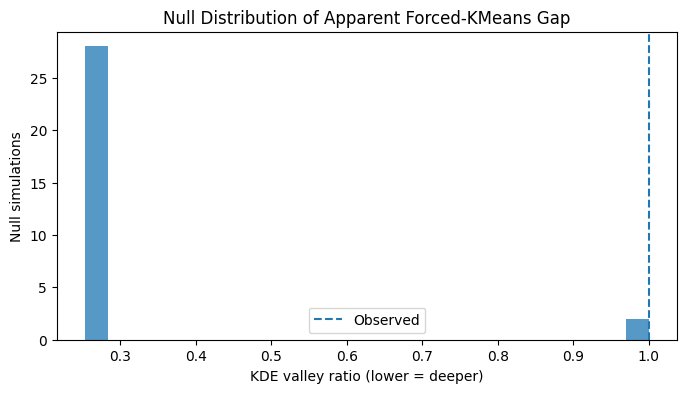

In [19]:
N_NULL=30
null_ratios=[]
for b in range(N_NULL):
    znull=np.column_stack([rng.permutation(Z_full[:,j]) for j in range(Z_full.shape[1])])
    f=KMeans(n_clusters=2,random_state=RANDOM_STATE+b+1000,n_init=10).fit(znull)
    xnull,_=separation_axis(znull,f.labels_,f.cluster_centers_)
    stat=kde_valley_stat(xnull)
    null_ratios.append(stat["gap_ratio"])
null_ratios=np.asarray(null_ratios,float)
obs=overall_gap["gap_ratio"]
p_null=(1+np.sum(null_ratios<=obs))/(1+len(null_ratios))
print(f"Observed forced-k2 gap ratio: {obs:.3f}")
print(f"Null median gap ratio: {np.nanmedian(null_ratios):.3f}")
print(f"Empirical p-value for a valley at least this deep: {p_null:.4f}")
plt.figure(figsize=(8,4));plt.hist(null_ratios,bins=25,alpha=.75);plt.axvline(obs,linestyle="--",label="Observed")
plt.xlabel("KDE valley ratio (lower = deeper)");plt.ylabel("Null simulations");plt.title("Null Distribution of Apparent Forced-KMeans Gap");plt.legend();plt.show()

##### The observed valley ratio is 1.0 (no valley), whereas the permutation null gives ratios near 0.26 in almost every simulation. The reported empirical *p* = 1.0 therefore only says that the observed data are *less* bimodal than the null — it is **not** a calibrated test of a gap. Sections 17A–17C diagnose why the permutation null is bimodal and replace it with a null that preserves the correlation structure.

## 17A. Why does the permutation null produce valleys?

Candidate explanations are tested one at a time: imputed values (compare the complete-case matrix), a single dominant column (replace each column in turn by Gaussian noise), generic KMeans behaviour (Gaussian noise with the observed covariance), and loss of correlation structure (Gaussian copula that keeps marginals *and* correlations).

### Table 17A — Null models compared

In [20]:
rng_null = np.random.default_rng(2026)
N_DIAG = 30

def forced_k2_stats(M, seed):
    f = KMeans(n_clusters=2, random_state=seed, n_init=10).fit(M)
    x, _ = separation_axis(M, f.labels_, f.cluster_centers_)
    s = kde_valley_stat(x)
    return s["gap_ratio"], s["modes"], diptest.dipstat(x)

def summarize_null(name, generator, n=N_DIAG):
    res = np.array([forced_k2_stats(generator(), 1000 + b) for b in range(n)])
    return [name, np.median(res[:, 0]), np.mean(res[:, 1] >= 2), np.median(res[:, 2])]

permute = lambda M: np.column_stack([rng_null.permutation(M[:, j]) for j in range(M.shape[1])])
rows = [summarize_null("Permuted columns (legacy null)", lambda: permute(Z_full)),
        summarize_null("Permuted columns, complete cases only", lambda: permute(Z_cc))]
for j, f in enumerate(FEATURES):
    def gen(j=j):
        M = permute(Z_full); M[:, j] = rng_null.standard_normal(len(M)); return M
    rows.append(summarize_null(f"Permuted, {f} replaced by N(0,1)", gen))
mu_, cov_ = Z_full.mean(0), np.cov(Z_full.T)
rows.append(summarize_null("Gaussian, observed covariance", lambda: rng_null.multivariate_normal(mu_, cov_, size=len(Z_full))))
rows.append(summarize_null("Gaussian copula (observed marginals + correlations)", make_copula_generator(Z_full, rng_null)))
diag_table = pd.DataFrame(rows, columns=["Null model", "Median valley ratio", "Share with >=2 KDE modes", "Median dip statistic"])
display(diag_table.round(4))

obs_ratio, obs_modes, obs_dip = forced_k2_stats(Z_full, RANDOM_STATE)
print(f"Observed forced-k2 axis: valley ratio={obs_ratio:.3f}, KDE modes={obs_modes}, dip statistic={obs_dip:.4f}")
print("Skewness of standardized columns:", dict(zip(FEATURES, pd.DataFrame(Z_full, columns=FEATURES).skew().round(2))))
print("Share of imputed values in pl_rade:", round(float(df['pl_rade'].isna().mean()), 3))
print("SUMMARY: replacing only pl_rade removes the artifact; a Gaussian copula null also produces no valley.")

,Null model,Median valley ratio,Share with >=2 KDE modes,Median dip statistic
0,Permuted columns (legacy null),0.2614,0.9333,0.0207
1,"Permuted columns, complete cases only",0.3231,1.0000,0.0524
2,"Permuted, pl_bmasse replaced by N(0,1)",0.2606,0.9667,0.0206
3,"Permuted, pl_rade replaced by N(0,1)",1.0000,0.0667,0.0072
4,"Permuted, pl_orbper replaced by N(0,1)",0.2607,1.0000,0.0206
5,"Permuted, st_teff replaced by N(0,1)",0.2594,0.9667,0.0206
6,"Permuted, st_mass replaced by N(0,1)",0.2614,0.9333,0.0206
7,"Permuted, st_rad replaced by N(0,1)",0.2596,0.9667,0.0206
8,"Permuted, st_met replaced by N(0,1)",0.2604,0.9667,0.0206
9,"Gaussian, observed covariance",1.0000,0.0000,0.0028


Observed forced-k2 axis: valley ratio=1.000, KDE modes=1, dip statistic=0.0025
Skewness of standardized columns: {'pl_bmasse': -0.43, 'pl_rade': 1.43, 'pl_orbper': 1.62, 'st_teff': 11.69, 'st_mass': 0.16, 'st_rad': 4.41, 'st_met': -0.74}
Share of imputed values in pl_rade: 0.256
SUMMARY: replacing only pl_rade removes the artifact; a Gaussian copula null also produces no valley.


##### The permutation null is bimodal because of one column. Replacing only `pl_rade` with Gaussian noise removes the artifact (median valley ratio 1.0; two or more modes in about 7% of runs), whereas replacing any other column leaves it unchanged (about 0.26). Radius is strongly skewed (skewness 1.43) and 25.6% of its values are a single imputed value, but imputation is not the sole cause, because the permuted complete-case matrix is bimodal too (0.323; two or more modes in every run). Gaussian noise with the observed covariance and a Gaussian copula that keeps both the marginals and the correlations both give no valley (ratio 1.0, no bimodal runs). The permutation null therefore keeps the radius marginal but discards the correlations that blend it in the real data, and is **not** a valid reference distribution. The precise mechanism by which the radius marginal drives the split was not analysed further; the replacement null below does not depend on it.

## 17B. Calibrated null: Gaussian copula with the dip statistic

The null keeps every marginal distribution and the rank correlations between features but contains no cluster structure. The statistic is Hartigan's dip statistic of the forced two-cluster separation coordinate — a continuous measure of departure from unimodality. The *p*-value is the fraction of null dip statistics at least as large as the observed one. A power check plants a two-population structure of increasing separation in copula data and records how often the test rejects at 5%.

### Table 17B — Calibrated null and power check

Observed dip = 0.0025; copula-null dip median = 0.0024 (2.5-97.5%: 0.0018-0.0033)
Empirical p (null dip >= observed) = 0.379   [N=500]
Copula-null share with >=2 KDE modes: 0.000; median valley ratio 1.000


,Planted shift (SD units),Rejection rate at 5%
0,0,0.033333
1,1,0.066667
2,2,0.533333
3,3,1.000000
4,4,1.000000


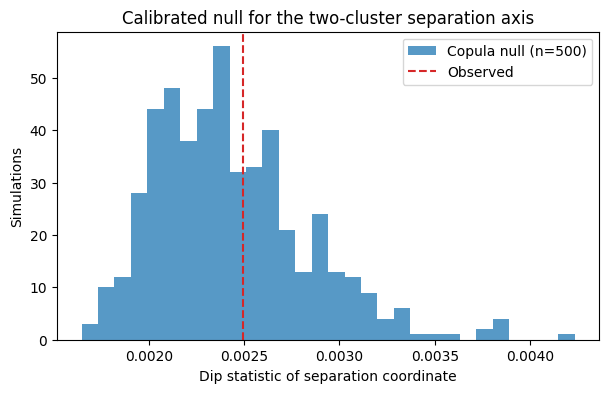

SUMMARY: observed dip 0.0025 vs copula-null median 0.0024, p = 0.379; power 0.53 at shift 2 and 1.00 at shift 4.


In [21]:
N_COPULA = 500
gen_copula = make_copula_generator(Z_full, np.random.default_rng(2027))
null_stats = np.array([forced_k2_stats(gen_copula(), 5000 + b) for b in range(N_COPULA)])
null_dip = null_stats[:, 2]
p_dip = (1 + np.sum(null_dip >= obs_dip)) / (1 + N_COPULA)
print(f"Observed dip = {obs_dip:.4f}; copula-null dip median = {np.median(null_dip):.4f} "
      f"(2.5-97.5%: {np.percentile(null_dip, 2.5):.4f}-{np.percentile(null_dip, 97.5):.4f})")
print(f"Empirical p (null dip >= observed) = {p_dip:.3f}   [N={N_COPULA}]")
print(f"Copula-null share with >=2 KDE modes: {np.mean(null_stats[:, 1] >= 2):.3f}; median valley ratio {np.median(null_stats[:, 0]):.3f}")

# Power: plant a second population (30% of rows shifted along mass/radius/period) in copula data
rng_pow = np.random.default_rng(2028)
gen_pow = make_copula_generator(Z_full, rng_pow)
direction = np.array([1, 1, 1, 0, 0, 0, 0]) / np.sqrt(3)
N_POWER = 30
power_rows = []
for shift in [0, 1, 2, 3, 4]:
    rej = 0
    for rep in range(N_POWER):
        M = gen_pow(); planted = rng_pow.random(len(M)) < 0.30; M[planted] += shift * direction
        dp = forced_k2_stats(M, 9000 + rep)[2]
        rej += ((1 + np.sum(null_dip >= dp)) / (1 + N_COPULA)) < 0.05
    power_rows.append([shift, rej / N_POWER])
power_table = pd.DataFrame(power_rows, columns=["Planted shift (SD units)", "Rejection rate at 5%"])
display(power_table)

plt.figure(figsize=(7, 4)); plt.hist(null_dip, bins=30, alpha=.75, label=f"Copula null (n={N_COPULA})")
plt.axvline(obs_dip, color="C3", ls="--", label="Observed"); plt.xlabel("Dip statistic of separation coordinate")
plt.ylabel("Simulations"); plt.legend(); plt.title("Calibrated null for the two-cluster separation axis"); plt.show()
print(f"SUMMARY: observed dip {obs_dip:.4f} vs copula-null median {np.median(null_dip):.4f}, p = {p_dip:.3f}; "
      f"power {power_rows[2][1]:.2f} at shift 2 and {power_rows[4][1]:.2f} at shift 4.")

##### The observed dip statistic (0.0025) is indistinguishable from the calibrated null (median 0.0024; 95% range 0.0018–0.0033; empirical *p* = 0.379), and none of the copula-null simulations shows two KDE modes. The test is not merely insensitive: with a planted second population it rejects 3% of the time when nothing is planted, 53% at a shift of 2 standardized units and 100% at 3 or more. The forced two-cluster separation axis therefore behaves like data with the same marginals and correlations but **no** cluster structure. This supersedes the permutation-null result of Section 17.

## 18. Within-method gap analysis

A discovery method is only allowed to contribute evidence about a gap when it actually contains enough planets on **both sides** of the forced two-cluster partition.

### Table 14 — Two-sided support and within-method KDE modality

In [22]:
gap_rows=[]
for method in major_methods:
    mask=df["discoverymethod"].eq(method).to_numpy()
    labs=lab2[mask]; coords=sep[mask]
    n0=int(np.sum(labs==0));n1=int(np.sum(labs==1)); n=len(labs)
    eligible=(n0>=20 and n1>=20)
    stat=kde_valley_stat(coords) if eligible else {"modes":np.nan,"gap_ratio":np.nan,"valley":np.nan}
    gap_rows.append([method,n,n0,n1,100*n0/n if n else np.nan,100*n1/n if n else np.nan,eligible,stat.get("modes"),stat.get("gap_ratio"),stat.get("valley")])
gap_method=pd.DataFrame(gap_rows,columns=["Method","N","Cluster 0 N","Cluster 1 N","Cluster 0 %","Cluster 1 %","Eligible: >=20 each side","KDE modes","Within-method valley ratio","Valley location"])
display(gap_method.round(3))
print("Important: an ineligible one-sided method is NOT evidence that a gap persists.")

,Method,N,Cluster 0 N,Cluster 1 N,Cluster 0 %,Cluster 1 %,Eligible: >=20 each side,KDE modes,Within-method valley ratio,Valley location
0,Transit,4501,1129,3372,25.083,74.917,True,1.0,1.0,NaN
1,Radial Velocity,1166,656,510,56.261,43.739,True,1.0,1.0,NaN
2,Imaging,92,63,29,68.478,31.522,True,1.0,1.0,NaN
3,Microlensing,266,9,257,3.383,96.617,False,NaN,NaN,NaN


Important: an ineligible one-sided method is NOT evidence that a gap persists.


##### Transit, Radial Velocity, and Imaging have enough observations on both sides for this diagnostic, yet each shows only **one KDE mode**. Microlensing is strongly one-sided and is therefore not counted as evidence for or against an internal gap.


## 19. Shared observational support

Even two-sided methods may observe different ranges of mass and orbital period. Pairwise central-support overlap is therefore checked before interpreting between-method differences.

### Table 15 — Pairwise common-support diagnostic

In [23]:
from itertools import combinations

eligible_methods=gap_method.loc[gap_method["Eligible: >=20 each side"],"Method"].tolist()
print("Eligible methods:",eligible_methods)
print("Common support is checked pairwise because requiring all methods to overlap can create an empty region.")

pair_rows=[]
for m1,m2 in combinations(eligible_methods,2):
    pair=[m1,m2]
    bounds={}
    valid=True
    for var in ["pl_orbper","pl_bmasse"]:
        lows=[]; highs=[]
        for m in pair:
            s=df.loc[df["discoverymethod"].eq(m),var].dropna()
            lows.append(s.quantile(.05)); highs.append(s.quantile(.95))
        lo,hi=max(lows),min(highs)
        bounds[var]=(lo,hi)
        if lo>=hi: valid=False
    if not valid:
        pair_rows.append([m1,m2,False,0,0,0,0,"No joint central mass-period support"])
        continue
    support=df["discoverymethod"].isin(pair).to_numpy()
    for var,(lo,hi) in bounds.items():
        support &= df[var].between(lo,hi).fillna(False).to_numpy()
    counts=[]
    for m in pair:
        mm=support & df["discoverymethod"].eq(m).to_numpy()
        labs=lab2[mm]
        counts.append((int(mm.sum()),int(np.sum(labs==0)),int(np.sum(labs==1))))
    pair_rows.append([m1,m2,True,counts[0][0],counts[1][0],counts[0][1],counts[0][2],f"{m2}: C0={counts[1][1]}, C1={counts[1][2]}"])

pair_support=pd.DataFrame(pair_rows,columns=["Method 1","Method 2","Central support overlaps","Method 1 N","Method 2 N","Method 1 C0","Method 1 C1","Method 2 cluster counts / note"])
display(pair_support)

Eligible methods: ['Transit', 'Radial Velocity', 'Imaging']
Common support is checked pairwise because requiring all methods to overlap can create an empty region.


,Method 1,Method 2,Central support overlaps,Method 1 N,Method 2 N,Method 1 C0,Method 1 C1,Method 2 cluster counts / note
0,Transit,Radial Velocity,True,761,326,343,418,"Radial Velocity: C0=33, C1=293"
1,Transit,Imaging,False,0,0,0,0,No joint central mass-period support
2,Radial Velocity,Imaging,True,28,0,28,0,"Imaging: C0=0, C1=0"


##### This check prevents the thesis from comparing discovery methods in parameter regions where one method has little or no observational coverage. It makes the selection-effect comparison more conservative.

## 20. Bootstrap uncertainty for the gap diagnostic

The forced two-cluster density diagnostic is repeated across bootstrap samples to check whether evidence for two modes appears consistently.

In [24]:
B_GAP=1000
gap_boot=[]; bimodal_boot=0
for b in range(B_GAP):
    idx=rng.integers(0,len(sep),len(sep))
    st=kde_valley_stat(sep[idx])
    gap_boot.append(st["gap_ratio"])
    if st["modes"]>=2: bimodal_boot+=1
gap_boot=np.asarray(gap_boot,float)
ci_gap=np.nanpercentile(gap_boot,[2.5,97.5])
print(f"Forced-k2 overall gap ratio={overall_gap['gap_ratio']:.3f}; bootstrap 95% interval [{ci_gap[0]:.3f}, {ci_gap[1]:.3f}]")
print(f"Bootstrap samples with >=2 KDE modes: {bimodal_boot}/{B_GAP} ({100*bimodal_boot/B_GAP:.1f}%)")

Forced-k2 overall gap ratio=1.000; bootstrap 95% interval [1.000, 1.000]
Bootstrap samples with >=2 KDE modes: 0/1000 (0.0%)


##### None of the bootstrap samples produces a stable two-mode density pattern. The earlier physical-gap claim is therefore not supported by the revised robustness analysis.

## 21. Matched within-method dip tests and threshold sensitivity

The peak-prominence rule of Section 18 needs an analyst-chosen threshold. A threshold-free alternative is to compute the dip statistic of each eligible method's projection on the global separation axis and compare it with a null built from *that method's own* marginals and correlations (a method-specific Gaussian copula). Three tests are run, so a Bonferroni-adjusted *p* is also reported. Two follow-ups test (i) whether the Radial Velocity result depends on the imputed radius, by removing the radius component from the axis, and (ii) the sensitivity of the mode count to the prominence threshold.

### Table 21A — Matched dip tests by method
### Table 21B — Radial Velocity dip test with the radius component removed
### Table 21C — KDE mode count and valley ratio versus prominence threshold

In [25]:
N_METHOD_NULL = 500
d_axis = sep_direction
rng_m = np.random.default_rng(2029)

def matched_dip(mask, axis, n_null=N_METHOD_NULL):
    Zm = Z_full[mask]
    gen = make_copula_generator(Zm, rng_m)
    nd = np.array([diptest.dipstat(gen() @ axis) for _ in range(n_null)])
    od = diptest.dipstat(Zm @ axis)
    return od, np.median(nd), (1 + np.sum(nd >= od)) / (1 + n_null)

rows = []
for method in ["Transit", "Radial Velocity", "Imaging"]:
    mask = df["discoverymethod"].eq(method).to_numpy()
    od, nm, p = matched_dip(mask, d_axis)
    rows.append([method, int(mask.sum()), od, nm, p, min(1.0, 3 * p)])
within_dip = pd.DataFrame(rows, columns=["Method", "N", "Observed dip", "Null median dip", "p", "Bonferroni p (x3)"])
print("TABLE 21A"); display(within_dip.round(4))

# 21B: remove the radius component from the axis, Radial Velocity only
ri = FEATURES.index("pl_rade")
d_norad = d_axis.copy(); d_norad[ri] = 0; d_norad /= np.linalg.norm(d_norad)
mask_rv = df["discoverymethod"].eq("Radial Velocity").to_numpy()
od2, nm2, p2 = matched_dip(mask_rv, d_norad)
print("TABLE 21B"); display(pd.DataFrame([["Radial Velocity, radius component removed", od2, nm2, p2]],
      columns=["Case", "Observed dip", "Null median dip", "p"]).round(4))
print("Radius loading on the separation axis:", round(float(d_axis[ri]), 3))
print("Radial Velocity share of planets with imputed radius:", round(float(df.loc[mask_rv, 'pl_rade'].isna().mean()), 3))

# 21C: prominence sweep
def valley_stat_th(x, th, grid_n=1200):
    grid = np.linspace(np.quantile(x, .002), np.quantile(x, .998), grid_n)
    den = gaussian_kde(x)(grid)
    peaks, _ = find_peaks(den, prominence=th * den.max())
    if len(peaks) < 2: return len(peaks), 1.0
    a, b = np.sort(peaks[np.argsort(den[peaks])[-2:]])
    return len(peaks), float(den[a + np.argmin(den[a:b + 1])] / min(den[a], den[b]))

sweep = []
subsets = {"All planets": np.ones(len(df), bool)}
subsets.update({m: df["discoverymethod"].eq(m).to_numpy() for m in ["Transit", "Radial Velocity", "Imaging"]})
for name, mk in subsets.items():
    for th in [0.005, 0.01, 0.02, 0.03, 0.05]:
        nmodes, ratio = valley_stat_th(sep[mk], th)
        sweep.append([name, th, nmodes, ratio])
sweep = pd.DataFrame(sweep, columns=["Subset", "Prominence threshold", "KDE modes", "Valley ratio"])
print("TABLE 21C"); display(sweep.pivot(index="Subset", columns="Prominence threshold", values=["KDE modes", "Valley ratio"]).round(3))

# dip statistic on PC1-PC3 versus the full-sample copula null
gen_pc = make_copula_generator(Z_full, np.random.default_rng(2030))
null_pc = np.array([[diptest.dipstat(M @ pca.components_[k]) for k in range(3)] for M in (gen_pc() for _ in range(200))])
pc_rows = []
for k in range(3):
    od = diptest.dipstat(Z_full @ pca.components_[k])
    pc_rows.append([f"PC{k+1}", od, np.median(null_pc[:, k]), (1 + np.sum(null_pc[:, k] >= od)) / 201])
print("Dip statistic on principal-component coordinates"); display(pd.DataFrame(pc_rows, columns=["Coordinate", "Observed dip", "Copula-null median", "p"]).round(4))

TABLE 21A


,Method,N,Observed dip,Null median dip,p,Bonferroni p (x3)
0,Transit,4501,0.0029,0.0028,0.4451,1.0000
1,Radial Velocity,1166,0.0114,0.0070,0.0100,0.0299
2,Imaging,92,0.0236,0.0285,0.8583,1.0000


TABLE 21B


,Case,Observed dip,Null median dip,p
0,"Radial Velocity, radius component removed",0.0118,0.0072,0.006


Radius loading on the separation axis: -0.525
Radial Velocity share of planets with imputed radius: 0.973
TABLE 21C


KDE modes                         Valley ratio                          
Prominence threshold     0.005 0.010 0.020 0.030 0.050        0.005  0.010  0.020 0.030 0.050
Subset                                                                                       
All planets                1.0   1.0   1.0   1.0   1.0        1.000  1.000  1.000   1.0   1.0
Imaging                    1.0   1.0   1.0   1.0   1.0        1.000  1.000  1.000   1.0   1.0
Radial Velocity            2.0   2.0   2.0   1.0   1.0        0.964  0.964  0.964   1.0   1.0
Transit                    1.0   1.0   1.0   1.0   1.0        1.000  1.000  1.000   1.0   1.0

Dip statistic on principal-component coordinates


,Coordinate,Observed dip,Copula-null median,p
0,PC1,0.0019,0.0023,0.9303
1,PC2,0.0019,0.0023,0.9055
2,PC3,0.0031,0.0025,0.1144


##### Transit (*p* = 0.445) and Imaging (*p* = 0.858) are consistent with unimodality against their own matched nulls. Radial Velocity is not: *p* = 0.010 (Bonferroni-adjusted 0.030). This departure is **not** produced by the imputed radius — removing the radius component from the axis gives *p* = 0.006 — although 97.3% of Radial Velocity radii are imputed. The departure is shallow: the valley ratio is 0.964 whenever the second peak is counted (prominence thresholds up to 2%) and the mode disappears at 3%. For all planets the axis has one mode at every threshold, and the dip statistics of PC1–PC3 are consistent with the copula null (*p* = 0.93, 0.91, 0.11). Radial Velocity therefore shows a weak, statistically detectable departure from unimodality but not a deep valley, and the two-mode count for that method depends on the prominence threshold.

## 22. Multiple-imputation sensitivity

Median imputation places a large share of the sample at a single value for mass and radius. As an alternative, five stochastic imputations are drawn with `IterativeImputer(sample_posterior=True)` on the log-transformed features; each completed data set is standardized, clustered, and tested. Reported per imputation: preferred *k* by silhouette, silhouette at *k* = 3, agreement (ARI) between the *k* = 3 partition and the primary partition, Cramér's V for *k* = 3, and the modality of the forced two-cluster separation axis.

### Table 22 — Multiple-imputation sensitivity

In [26]:
Xlog = df[FEATURES].copy()
for c in LOG_FEATURES: Xlog[c] = np.log10(Xlog[c] + 1)
grp_all = df["discoverymethod"].where(df["discoverymethod"].isin(keep_methods), "Other")
N_MI = 5
mi_rows = []
for m in range(N_MI):
    imp = IterativeImputer(sample_posterior=True, random_state=RANDOM_STATE + m, max_iter=15)
    Zmi = StandardScaler().fit_transform(imp.fit_transform(Xlog))
    sil = {k: silhouette_score(Zmi, KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit(Zmi).labels_) for k in range(2, 7)}
    bk = max(sil, key=sil.get)
    lab3 = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20).fit(Zmi).labels_
    f2 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=20).fit(Zmi)
    x2_, _ = separation_axis(Zmi, f2.labels_, f2.cluster_centers_)
    mi_rows.append([m + 1, bk, sil[bk], sil[3], adjusted_rand_score(lab_km, lab3),
                    cramers_v(pd.crosstab(lab3, grp_all)), kde_valley_stat(x2_)["modes"], diptest.dipstat(x2_)])
mi_table = pd.DataFrame(mi_rows, columns=["Imputation", "Best k", "Silhouette (best k)", "Silhouette (k=3)", "ARI vs primary (k=3)", "Cramer's V (k=3)", "KDE modes, forced k=2 axis", "Dip statistic"])
display(mi_table.round(3))
print(f"Primary (median imputation): best k = {best_k}, silhouette = {k_table.loc[k_table['k'].eq(best_k), 'Silhouette'].iloc[0]:.3f}, V = {V:.3f}")
vcol = "Cramer's V (k=3)"
print(f"Multiple imputation: best k values = {sorted(mi_table['Best k'].unique().tolist())}; "
      f"V(k=3) range = {mi_table[vcol].min():.3f}-{mi_table[vcol].max():.3f}; "
      f"ARI range = {mi_table['ARI vs primary (k=3)'].min():.3f}-{mi_table['ARI vs primary (k=3)'].max():.3f}")

,Imputation,Best k,Silhouette (best k),Silhouette (k=3),ARI vs primary (k=3),Cramer's V (k=3),"KDE modes, forced k=2 axis",Dip statistic
0,1,2,0.340,0.276,0.587,0.384,1,0.002
1,2,2,0.341,0.277,0.591,0.383,1,0.002
2,3,2,0.346,0.283,0.612,0.385,1,0.002
3,4,2,0.345,0.276,0.596,0.390,1,0.002
4,5,2,0.344,0.275,0.591,0.392,1,0.003


Primary (median imputation): best k = 3, silhouette = 0.339, V = 0.470
Multiple imputation: best k values = [2]; V(k=3) range = 0.383-0.392; ARI range = 0.587-0.612


##### In all five stochastic imputations the silhouette prefers *k* = 2 (0.340–0.346), not *k* = 3. The *k* = 3 partition agrees only moderately with the primary partition (ARI 0.587–0.612), and Cramér's V for *k* = 3 is 0.383–0.392, lower than the 0.470 obtained with median imputation. Median imputation therefore inflates part of the cluster–method association, and the preferred number of clusters depends on the imputation strategy. The forced two-cluster separation axis remains unimodal in every imputation (one KDE mode), so the RQ2 finding is unaffected.

## 23. Alternative criteria for the number of clusters

The silhouette criterion alone selected *k* = 3. Three other criteria are computed on the primary standardized matrix: the Calinski–Harabasz index (higher is better), the Davies–Bouldin index (lower is better), and the BIC of a Gaussian mixture (lower is better).

### Table 23 — Criteria for *k*

In [27]:
crit_rows = []
for k in range(2, 9):
    lab = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit(Z_full).labels_
    bic = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=3).fit(Z_full).bic(Z_full)
    crit_rows.append([k, silhouette_score(Z_full, lab), calinski_harabasz_score(Z_full, lab), davies_bouldin_score(Z_full, lab), bic])
crit = pd.DataFrame(crit_rows, columns=["k", "Silhouette", "Calinski-Harabasz", "Davies-Bouldin", "GMM BIC"])
display(crit.round(3))
print(f"Best k by criterion: silhouette={int(crit.loc[crit['Silhouette'].idxmax(), 'k'])}, "
      f"Calinski-Harabasz={int(crit.loc[crit['Calinski-Harabasz'].idxmax(), 'k'])}, "
      f"Davies-Bouldin={int(crit.loc[crit['Davies-Bouldin'].idxmin(), 'k'])}, "
      f"GMM BIC={int(crit.loc[crit['GMM BIC'].idxmin(), 'k'])} (lowest within k<=8)")

,k,Silhouette,Calinski-Harabasz,Davies-Bouldin,GMM BIC
0,2,0.279,1343.637,1.815,87797.530
1,3,0.339,1332.813,1.298,68030.940
2,4,0.327,1315.124,1.048,26636.726
3,5,0.290,1413.174,1.175,25056.561
4,6,0.306,1531.195,1.080,23966.326
5,7,0.290,1510.359,1.075,22592.448
6,8,0.296,1464.170,1.076,16608.594


Best k by criterion: silhouette=3, Calinski-Harabasz=6, Davies-Bouldin=4, GMM BIC=8 (lowest within k<=8)


##### The criteria disagree: silhouette favours *k* = 3, Davies–Bouldin *k* = 4, Calinski–Harabasz *k* = 6, and the Gaussian-mixture BIC is still falling at the largest value tried (*k* = 8). No criterion other than the silhouette supports *k* = 3. The very large BIC drop between *k* = 3 and *k* = 4 is consistent with mixture components fitting point masses created by imputation, though that was not tested. The number of regimes should be treated as unresolved.

## 24. Like-for-like association within shared observational support

Transit and Radial Velocity are the only pair with joint central mass–period support (Section 19). Inside that region both methods can detect planets, so an association between regime and method there is less easily attributed to where each method looks. Two versions are computed: (a) the primary regimes, and (b) a fresh clustering using only features that are *measured* (orbital period and the four stellar features), on planets with no imputation, with a bootstrap interval for Cramér's V.

### Table 24 — Association within shared Transit–Radial Velocity support

In [28]:
sup = df["discoverymethod"].isin(["Transit", "Radial Velocity"]).to_numpy()
for var in ["pl_orbper", "pl_bmasse"]:
    lo = max(df.loc[df.discoverymethod.eq(m), var].dropna().quantile(.05) for m in ["Transit", "Radial Velocity"])
    hi = min(df.loc[df.discoverymethod.eq(m), var].dropna().quantile(.95) for m in ["Transit", "Radial Velocity"])
    sup &= df[var].between(lo, hi).fillna(False).to_numpy()
sub = df[sup]
print("Shared-support planets:", sub["discoverymethod"].value_counts().to_dict())
t_a = pd.crosstab(sub["discoverymethod"], lab_km[sup])
print("(a) primary regimes inside the shared region"); display(t_a)
print(f"    chi2 p = {chi2_contingency(t_a)[1]:.2e}; Cramer's V = {cramers_v(t_a):.3f}")

feat_m = ["pl_orbper", "st_teff", "st_mass", "st_rad", "st_met"]
cc_sub = sub.dropna(subset=feat_m).copy()
print("(b) measured-only features, no imputation:", cc_sub["discoverymethod"].value_counts().to_dict())
_, Zs, _, _ = preprocess(cc_sub, feat_m, impute=False)
rng_l = np.random.default_rng(2031)
lfl_rows = []
for k in [2, 3]:
    lab = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30).fit(Zs).labels_
    tab = pd.crosstab(cc_sub["discoverymethod"], lab)
    vb = []
    for _ in range(500):
        idx = rng_l.integers(0, len(lab), len(lab))
        tb = pd.crosstab(cc_sub["discoverymethod"].to_numpy()[idx], lab[idx])
        if min(tb.shape) >= 2: vb.append(cramers_v(tb))
    lfl_rows.append([k, len(cc_sub), silhouette_score(Zs, lab), cramers_v(tab), *np.percentile(vb, [2.5, 97.5])])
    display(tab)
lfl = pd.DataFrame(lfl_rows, columns=["k", "N", "Silhouette", "Cramer's V", "CI low", "CI high"])
display(lfl.round(3))

Shared-support planets: {'Transit': 761, 'Radial Velocity': 326}
(a) primary regimes inside the shared region


col_0,0,1,2
discoverymethod,,,
Radial Velocity,7,315,4
Transit,2,400,359


    chi2 p = 8.21e-49; Cramer's V = 0.451
(b) measured-only features, no imputation: {'Transit': 668, 'Radial Velocity': 190}


col_0,0,1
discoverymethod,,
Radial Velocity,98,92
Transit,495,173


col_0,0,1,2
discoverymethod,,,
Radial Velocity,68,79,43
Transit,120,189,359


,k,N,Silhouette,Cramer's V,CI low,CI high
0,2,858,0.322,0.199,0.134,0.274
1,3,858,0.273,0.265,0.214,0.327


##### Inside the shared Transit–Radial Velocity region (761 Transit and 326 Radial Velocity planets) the primary regimes remain strongly associated with method (V = 0.451), but this is confounded by imputation: 97% of Radial Velocity radii are imputed at the sample median. Using only measured features (orbital period and the four stellar features, no imputation; 668 Transit and 190 Radial Velocity planets), the association is much weaker but non-zero: V = 0.199 (95% CI 0.134–0.274) for *k* = 2 and 0.265 (0.214–0.327) for *k* = 3, with modest silhouettes (0.322, 0.273). A like-for-like comparison thus supports a real but moderate dependence of regime on method, well below the 0.470 from the full imputed sample.

## 25. Supplementary tables quoted in the thesis

Descriptive checks used in the write-up: HDBSCAN cluster sizes, the share of imputed values in each primary regime, the orbital-ablation partition, the composition and profiles of the complete-case and radius-centred solutions, and the earlier eight-feature specification (adds `pl_orbsmax` and `st_logg`, no radius) evaluated with the same modality diagnostics.

### Tables 25A–25F

In [29]:
print("25A. HDBSCAN label counts (-1 = noise):", pd.Series(lab_hdb).value_counts().sort_index().to_dict())

imp_share = pd.DataFrame({"N": pd.Series(lab_km).value_counts().sort_index(),
    "Mass imputed %": df["pl_bmasse"].isna().groupby(lab_km).mean() * 100,
    "Radius imputed %": df["pl_rade"].isna().groupby(lab_km).mean() * 100,
    "Mean imputed features": df[FEATURES].isna().sum(axis=1).groupby(lab_km).mean()})
print("25B. Imputed share by primary regime"); display(imp_share.round(2))

print("25C. Orbital-ablation partition: sizes", np.bincount(fit_noorb.labels_).tolist(),
      "| ARI vs primary:", round(adjusted_rand_score(lab_km, fit_noorb.labels_), 3))
display(ablation_contingency_table)

print("25D. Complete-case sample composition:", df_cc["discoverymethod"].value_counts().to_dict())
display(df_cc.assign(c=cc_fit.labels_).groupby("c")[FEATURES].median().round(2))

print("25E. Radius-centred regimes: sizes", np.bincount(rad_fit.labels_).tolist())
display(df.assign(c=rad_fit.labels_).groupby("c")[RADIUS_FEATURES].median().round(2))

OLD8 = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "st_teff", "st_mass", "st_rad", "st_met", "st_logg"]
d8 = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(df[OLD8]), columns=OLD8, index=df.index)
for c in ["pl_bmasse", "pl_orbper", "pl_orbsmax", "st_mass", "st_rad"]: d8[c] = np.log10(d8[c] + 1)
Z8 = StandardScaler().fit_transform(d8)
sil8 = {k: silhouette_score(Z8, KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50).fit(Z8).labels_) for k in range(2, 9)}
f8 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=50).fit(Z8)
x8, _ = separation_axis(Z8, f8.labels_, f8.cluster_centers_)
print("25F. Earlier 8-feature specification: silhouette by k", {k: round(v, 3) for k, v in sil8.items()})
print("     forced k=2 sizes", np.bincount(f8.labels_).tolist(), "| overall modality", kde_valley_stat(x8),
      "| dip", round(diptest.dipstat(x8), 4))
for m in ["Transit", "Radial Velocity", "Imaging"]:
    mk = df["discoverymethod"].eq(m).to_numpy()
    n0, n1 = int((f8.labels_[mk] == 0).sum()), int((f8.labels_[mk] == 1).sum())
    print(f"     {m}: n0={n0}, n1={n1}", kde_valley_stat(x8[mk]) if min(n0, n1) >= 20 else "ineligible")
print("     Cramer's V (k=2):", round(cramers_v(pd.crosstab(f8.labels_, grp_all)), 3))

25A. HDBSCAN label counts (-1 = noise): {-1: 1033, 0: 51, 1: 5023}
25B. Imputed share by primary regime


,N,Mass imputed %,Radius imputed %,Mean imputed features
0,695,2.73,94.96,1.97
1,4421,65.87,19.86,1.65
2,991,17.36,2.52,0.43


25C. Orbital-ablation partition: sizes [4514, 1396, 197] | ARI vs primary: 0.737


method_group,Imaging,Microlensing,Other,Radial Velocity,Transit
cluster,,,,,
0,38,265,55,724,3432
1,53,1,27,248,1067
2,1,0,0,194,2


25D. Complete-case sample composition: {'Transit': 1244, 'Radial Velocity': 28, 'Orbital Brightness Modulation': 1, 'Transit Timing Variations': 1}


,pl_bmasse,pl_rade,pl_orbper,st_teff,st_mass,st_rad,st_met
c,,,,,,,
0,280.95,12.78,4.13,5900.0,1.14,1.32,0.12
1,8.32,2.43,6.59,4975.0,0.80,0.77,0.00


25E. Radius-centred regimes: sizes [4330, 769, 1008]


,pl_rade,pl_orbper,st_teff,st_mass,st_rad,st_met
c,,,,,,
0,2.07,10.16,5459.1,0.87,0.88,0.00
1,3.88,884.25,5474.0,1.15,1.72,0.05
2,12.29,4.22,5849.0,1.10,1.23,0.12


25F. Earlier 8-feature specification: silhouette by k {2: 0.509, 3: 0.466, 4: 0.296, 5: 0.305, 6: 0.315, 7: 0.218, 8: 0.246}
     forced k=2 sizes [5431, 676] | overall modality {'modes': 1, 'gap_ratio': 1.0, 'valley': nan} | dip 0.0024
     Transit: n0=4471, n1=30 {'modes': 1, 'gap_ratio': 1.0, 'valley': nan}
     Radial Velocity: n0=632, n1=534 {'modes': 2, 'gap_ratio': 0.8614039811852304, 'valley': 0.6955297516457564, 'left_peak': -0.724358244635749, 'right_peak': 2.025975984381969}
     Imaging: n0=6, n1=86 ineligible
     Cramer's V (k=2): 0.651


## 26. Evidence summary

The main numerical findings are gathered here only **after** the individual analyses have been presented and interpreted.

### Table 26 — Evidence summary

In [30]:
evidence = []
evidence.append(["Primary KMeans best k", best_k, "Descriptive partition only"])
evidence.append(["Primary KMeans silhouette", float(k_table.loc[k_table['k'].eq(best_k), 'Silhouette'].iloc[0]), "Higher means cleaner geometric separation"])
evidence.append(["Best k by Calinski-Harabasz / Davies-Bouldin / GMM BIC", "%d / %d / %d" % (int(crit.loc[crit['Calinski-Harabasz'].idxmax(), 'k']), int(crit.loc[crit['Davies-Bouldin'].idxmin(), 'k']), int(crit.loc[crit['GMM BIC'].idxmin(), 'k'])), "Criteria disagree; no criterion other than silhouette supports k = 3"])
evidence.append(["GMM vs KMeans ARI", float(adjusted_rand_score(lab_km, lab_gmm)), "Cross-model agreement"])
evidence.append(["Cramer's V: cluster vs discovery method", V, f"95% bootstrap CI {ci_v[0]:.3f}–{ci_v[1]:.3f}"])
evidence.append(["Cramer's V after orbital ablation", V_ab, "Association remaining after orbital-period removal"])
evidence.append(["Cramer's V under multiple imputation (range)", "%.3f–%.3f" % (mi_table["Cramer's V (k=3)"].min(), mi_table["Cramer's V (k=3)"].max()), "Median imputation partly inflates the association"])
evidence.append(["Best k under multiple imputation", str(sorted(mi_table["Best k"].unique().tolist())), "Preferred k depends on the imputation strategy"])
evidence.append(["Cramer's V, shared Transit–RV support, measured features only", "%.3f (k=2), %.3f (k=3)" % tuple(lfl["Cramer's V"]), "Like-for-like association"])
evidence.append(["Complete-case best k", cc_best_k, f"N={len(df_cc)}; almost entirely Transit"])
evidence.append(["Radius-centred best k", rad_best, "Planet mass removed"])
evidence.append(["Forced-k2 silhouette", silhouette_score(Z_full, lab2), "Diagnostic for the earlier two-regime claim only"])
evidence.append(["Forced-k2 KDE modes", overall_gap["modes"], "Independent density check on separation coordinate"])
evidence.append(["Forced-k2 valley ratio", overall_gap["gap_ratio"], "Only evidence of a gap when >=2 modes exist"])
evidence.append(["Calibrated null: observed dip vs copula-null median", "%.4f vs %.4f" % (obs_dip, np.median(null_dip)), f"empirical p = {p_dip:.3f}; observed data are consistent with a cluster-free null"])
evidence.append(["Legacy permutation-null empirical p", p_null, "Not calibrated: the permutation null itself produces deep valleys"])
evidence.append(["Bootstrap samples with >=2 KDE modes", "%d / %d" % (bimodal_boot, B_GAP), "No stable two-mode pattern"])
evidence.append(["Within-method matched dip test p (Transit / RV / Imaging)", " / ".join("%.3f" % p for p in within_dip["p"]), "RV shows a weak departure from unimodality"])
display(pd.DataFrame(evidence, columns=["Evidence", "Result", "Interpretation note"]))

,Evidence,Result,Interpretation note
0,Primary KMeans best k,3,Descriptive partition only
1,Primary KMeans silhouette,0.338957,Higher means cleaner geometric separation
2,Best k by Calinski-Harabasz / Davies-Bouldin /...,6 / 4 / 8,Criteria disagree; no criterion other than sil...
3,GMM vs KMeans ARI,0.225534,Cross-model agreement
4,Cramer's V: cluster vs discovery method,0.470347,95% bootstrap CI 0.455–0.486
5,Cramer's V after orbital ablation,0.283353,Association remaining after orbital-period rem...
6,Cramer's V under multiple imputation (range),0.383–0.392,Median imputation partly inflates the association
7,Best k under multiple imputation,[2],Preferred k depends on the imputation strategy
8,"Cramer's V, shared Transit–RV support, measure...","0.199 (k=2), 0.265 (k=3)",Like-for-like association
9,Complete-case best k,2,N=1274; almost entirely Transit


## 27. Final Interpretation

### Answer to RQ1

The results show that machine learning can identify clear patterns in the exoplanet data, and some of these patterns are quite stable. For example, the bootstrap ARI was around 0.98, while the radius centred analysis was also very close to the main clustering result, with an ARI of 0.92.

At the same time, the exact number of clusters was not always the same. The median-imputed dataset preferred 3 clusters, while the complete-case and multiple imputation analyses preferred 2 clusters. Other criteria suggested 4 or 6 clusters, and GMM showed only limited agreement with the main KMeans result.

Another important finding is that cluster membership was clearly related to discovery method. In the main analysis, Cramér’s V was 0.470. Under multiple imputation it was around 0.38–0.39, and under more restricted like-for-like comparisons it was around 0.20–0.27. When orbital period was removed, the association dropped to 0.283.

Taken together, these results suggest that the observed clustering is not explained only by the physical properties of the planets. It is also influenced by how planets were discovered, how missing values were handled, and which features were included in the analysis.

### Answer to RQ2

The analysis did not find strong evidence for a genuine gap between two separate planet populations.

The main clustering result preferred 3 clusters rather than 2. When a 2-cluster solution was forced, the separation between the groups still did not show a clear two-peak pattern.

The dip test also did not show a significant difference from the cluster-free null model, with *p* = 0.38. None of the bootstrap samples showed two clear modes, and the Transit and Imaging samples were also unimodal.

Radial Velocity was the only discovery method that showed a small but statistically significant departure from unimodality, with *p* = 0.010. However, this result is still not strong enough to claim a separate planet population. It simply suggests that this area may be worth investigating further.

### Thesis Conclusion

Overall, the machine learning analysis identifies clear "data driven exoplanet population regimes", but the results are not strong enough to describe them as new natural planet classes.

The main finding is that the clustering structure is affected by several factors, including:

- discovery method
- missing data and the way it is handled
- feature selection
- clustering algorithm

This means that the patterns seen in the catalogue are real patterns in the observed data, but they are also strongly shaped by observational and methodological effects.

### Limitations

One limitation is that the NASA exoplanet catalogue contains information about detected planets and their discovery methods, but it does not provide complete survey-level information about detection efficiency.

Because of this, the thesis can examine how discovery method is related to the observed clustering, but it cannot fully measure the true completeness or detection bias of each survey.

Some thresholds used in the analysis were also practical methodological choices. These include the 3% prominence threshold, requiring at least 20 planets on each side of a comparison, and grouping discovery methods with fewer than 50 planets into an “Other” category. These choices were made to keep the analysis stable and interpretable, but they should not be treated as universal rules.